# Retail Sales Forecasting

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [88]:
def missing_data(input_data):
    '''
    This function returns dataframe with information about the percentage of nulls in each column and the column data type.
    
    input: pandas df
    output: pandas df
    
    '''
    
    total = input_data.isnull().sum()
    percent = (input_data.isnull().sum()/input_data.isnull().count()*100)
    table = pd.concat([total, percent], axis = 1, keys = ['Total', 'Percent'])
    types = []
    for col in input_data.columns: 
        dtype = str(input_data[col].dtype)
        types.append(dtype)
    table["Types"] = types
    return(pd.DataFrame(table))

def mape(actual, pred): 
    '''
    Mean Absolute Percentage Error (MAPE) Function
    
    input: list/series for actual values and predicted values
    output: mape value 
    '''
    actual, pred = np.array(actual), np.array(pred)
    return np.mean(np.abs((actual - pred) / actual)) * 100

In [89]:
df = pd.read_csv('retail_sales_sg.csv')

In [90]:
df.head()

,date,retail_sales_value_estimated
0,1997-Jan,2656
1,1997-Feb,1703
2,1997-Mar,2027
3,1997-Apr,1934
4,1997-May,1961


In [91]:
df.tail()

,date,retail_sales_value_estimated
336,2025-Jan,4547
337,2025-Feb,3793
338,2025-Mar,4300
339,2025-Apr,3924
340,2025-May,4239


In [92]:
missing_data(df)

,Total,Percent,Types
date,0,0.0,object
retail_sales_value_estimated,0,0.0,int64


In [93]:
df.dtypes

date                            object
retail_sales_value_estimated     int64
dtype: object

In [94]:
df['date'] = pd.to_datetime(df['date'])

/var/folders/j9/wsktvg6d2fjbry6zjtc84m740000gn/T/ipykernel_13081/3532345252.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [95]:
df['date'] = df['date'].dt.to_period('M')

In [96]:
df.head()

,date,retail_sales_value_estimated
0,1997-01,2656
1,1997-02,1703
2,1997-03,2027
3,1997-04,1934
4,1997-05,1961


In [97]:
df=df.set_index('date')

In [98]:
df.index

PeriodIndex(['1997-01', '1997-02', '1997-03', '1997-04', '1997-05', '1997-06',
             '1997-07', '1997-08', '1997-09', '1997-10',
             ...
             '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01',
             '2025-02', '2025-03', '2025-04', '2025-05'],
            dtype='period[M]', name='date', length=341)

<Axes: title={'center': 'Monthly Estimated Retail Sales (SG)'}, xlabel='date'>

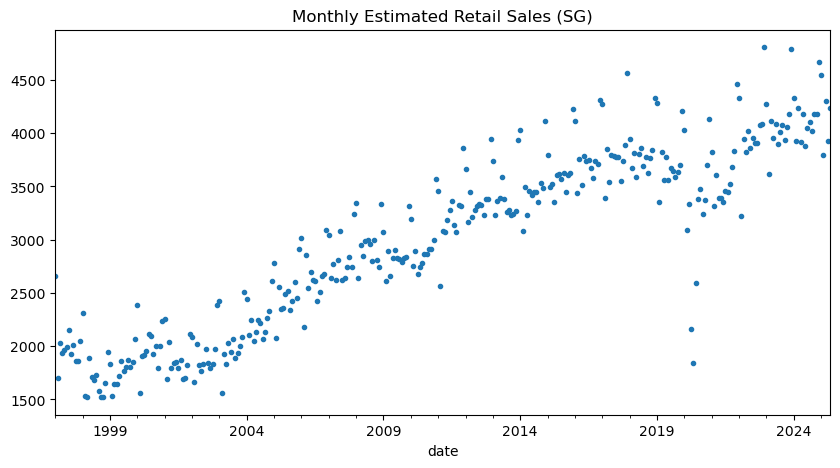

In [99]:
df.plot(style='.',figsize=(10,5),title ='Monthly Estimated Retail Sales (SG)',legend=False)

We can see a clear trend in the data over the years, with a drop we can likely assume was the effect of COVID-19.

There is also possible seasonal behaviour, which is expected of retail behaviour.

## Outlier Analysis

In [100]:
df_2020 = df.query('date.dt.year == 2020')
print(df_2020)

         retail_sales_value_estimated
date                                 
2020-01                          4026
2020-02                          3093
2020-03                          3332
2020-04                          2158
2020-05                          1842
2020-06                          2597
2020-07                          3387
2020-08                          3475
2020-09                          3240
2020-10                          3369
2020-11                          3698
2020-12                          4135


Adverse effect from 2020-04 to 2020-06 due to COVID-19.


In [101]:
###Adding COVID-19 indicator feature
df['is_covid'] = df.index.to_series().between('2020-04', '2020-06').astype(int)

In [102]:
df[df.index.year==2020]

,retail_sales_value_estimated,is_covid
date,,
2020-01,4026,0
2020-02,3093,0
2020-03,3332,0
2020-04,2158,1
2020-05,1842,1
2020-06,2597,1
2020-07,3387,0
2020-08,3475,0
2020-09,3240,0


## Feature Engineering

In [103]:
#Time Step Features
def create_features(df):
    """
    Creates time-step features (month, quarter, year) from the DataFrame's index.

    Args:
        df (pd.DataFrame): The input DataFrame with a DatetimeIndex.

    Returns:
        pd.DataFrame: The DataFrame with added time-step features.
    """
    df_copy = df.copy()

    # df_copy['hour'] = df_copy.index.hour # Uncomment if needed
    # df_copy['dayofweek'] = df_copy.index.dayofweek # Uncomment if needed
    df_copy['month'] = df_copy.index.month
    df_copy['quarter'] = df_copy.index.quarter
    df_copy['year'] = df_copy.index.year
    # df_copy['dayofyear'] = df_copy.index.dayofyear # Uncomment if needed

    return df_copy

In [104]:
df = create_features(df)

<Axes: xlabel='month', ylabel='retail_sales_value_estimated'>

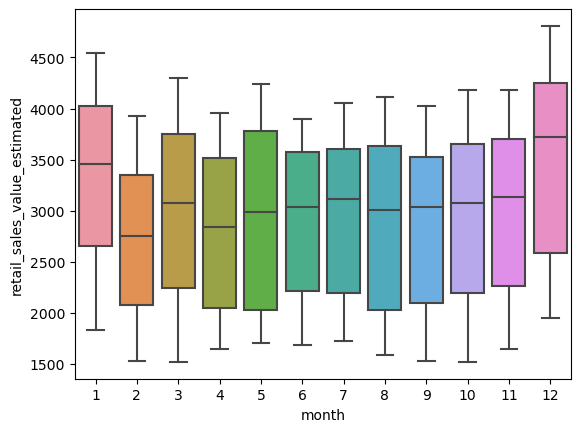

In [105]:
sns.boxplot(data=df,x='month',y='retail_sales_value_estimated')

Spending in SG tends to peak in January & December. We can assume that this is likely from new year & christmas spending.

In [34]:
# Lag Features
#df['sales_lag_1'] = df['retail_sales_value_estimated'].shift(1)
#df['sales_lag_2'] = df['retail_sales_value_estimated'].shift(2)

## Time Series Cross Validation

In [135]:
tss = TimeSeriesSplit(n_splits = 3, test_size = 12
                      , gap = 0)

fold = 0
preds = []
scores = []
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['quarter', 'month', 'year','is_covid']
    TARGET = 'retail_sales_value_estimated'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:linear',
                           max_depth=3,
                           learning_rate=0.01)
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

[0]	validation_0-rmse:2942.74891	validation_1-rmse:4028.04784
[100]	validation_0-rmse:1116.87263	validation_1-rmse:1760.95049
[200]	validation_0-rmse:454.21475	validation_1-rmse:917.74034
[300]	validation_0-rmse:222.45499	validation_1-rmse:566.83122
[400]	validation_0-rmse:147.23997	validation_1-rmse:419.89084
[500]	validation_0-rmse:123.75528	validation_1-rmse:317.04075
[600]	validation_0-rmse:113.31875	validation_1-rmse:243.97434


/Users/mengkiat/anaconda3/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [00:07:56] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[700]	validation_0-rmse:106.37120	validation_1-rmse:205.78482
[800]	validation_0-rmse:101.73019	validation_1-rmse:180.44246
[900]	validation_0-rmse:97.69572	validation_1-rmse:162.51953
[999]	validation_0-rmse:94.72596	validation_1-rmse:147.92555
[0]	validation_0-rmse:2990.78914	validation_1-rmse:4098.85573
[100]	validation_0-rmse:1135.41396	validation_1-rmse:1796.77021
[200]	validation_0-rmse:463.24331	validation_1-rmse:877.32959
[300]	validation_0-rmse:226.95577	validation_1-rmse:492.70744
[400]	validation_0-rmse:151.18296	validation_1-rmse:308.27131
[500]	validation_0-rmse:124.37377	validation_1-rmse:232.66783
[600]	validation_0-rmse:113.08988	validation_1-rmse:183.26691
[700]	validation_0-rmse:106.58736	validation_1-rmse:161.53189
[800]	validation_0-rmse:101.37958	validation_1-rmse:151.02874
[900]	validation_0-rmse:97.03739	validation_1-rmse:144.48456


/Users/mengkiat/anaconda3/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [00:07:56] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[999]	validation_0-rmse:93.93069	validation_1-rmse:138.56630
[0]	validation_0-rmse:3038.10190	validation_1-rmse:4127.80861
[100]	validation_0-rmse:1152.85758	validation_1-rmse:1753.17522
[200]	validation_0-rmse:468.84822	validation_1-rmse:815.72927
[300]	validation_0-rmse:230.18067	validation_1-rmse:439.88974
[400]	validation_0-rmse:153.27113	validation_1-rmse:264.57846
[500]	validation_0-rmse:127.04820	validation_1-rmse:185.88175
[600]	validation_0-rmse:114.29522	validation_1-rmse:143.55479
[700]	validation_0-rmse:107.14571	validation_1-rmse:125.81675
[800]	validation_0-rmse:102.16026	validation_1-rmse:117.30371


/Users/mengkiat/anaconda3/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [00:07:57] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[900]	validation_0-rmse:98.12761	validation_1-rmse:113.28456
[999]	validation_0-rmse:95.08447	validation_1-rmse:111.41729


In [136]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 132.5939
Fold scores:[147.9255505042701, 138.56629972923642, 111.28990440456352]


In [144]:
train = df[df.index < '2024-01']
test = df[df.index >= '2024-01']

train = create_features(train)
test = create_features(test)

FEATURES = ['quarter', 'month', 'year','is_covid']
TARGET = 'retail_sales_value_estimated'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:linear',
                           max_depth=3,
                           learning_rate=0.1)
reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

y_pred = reg.predict(X_test)
preds.append(y_pred)
score = np.sqrt(mean_squared_error(y_test, y_pred))
scores.append(score)

[0]	validation_0-rmse:2750.64468	validation_1-rmse:3785.83264
[100]	validation_0-rmse:91.94200	validation_1-rmse:173.50897
[200]	validation_0-rmse:74.87177	validation_1-rmse:154.12816
[300]	validation_0-rmse:67.73185	validation_1-rmse:151.19739
[337]	validation_0-rmse:66.37391	validation_1-rmse:150.91201


/Users/mengkiat/anaconda3/lib/python3.11/site-packages/xgboost/callback.py:386: UserWarning: [03:05:22] WARNING: /Users/runner/work/xgboost/xgboost/src/objective/regression_obj.cu:250: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


In [145]:
fi = pd.DataFrame(data=reg.feature_importances_,
                  index=reg.feature_names_in_,
                 columns=['importance'])

<Axes: title={'center': 'Feature Importance'}>

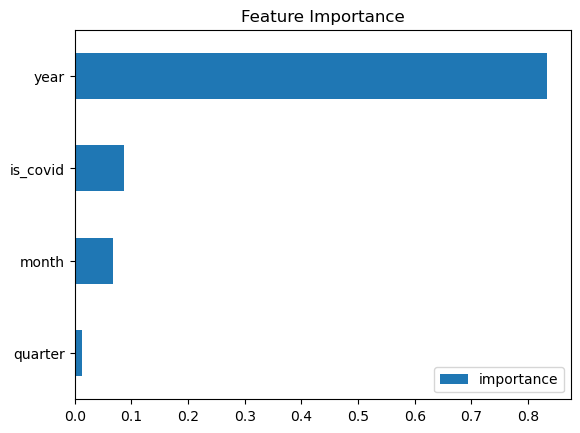

In [146]:
fi.sort_values('importance').plot(kind='barh',title='Feature Importance')

In [147]:
test['prediction'] = reg.predict(X_test)

In [148]:
final_df = df.merge(test[['prediction']], how ='left', left_index=True, right_index=True)

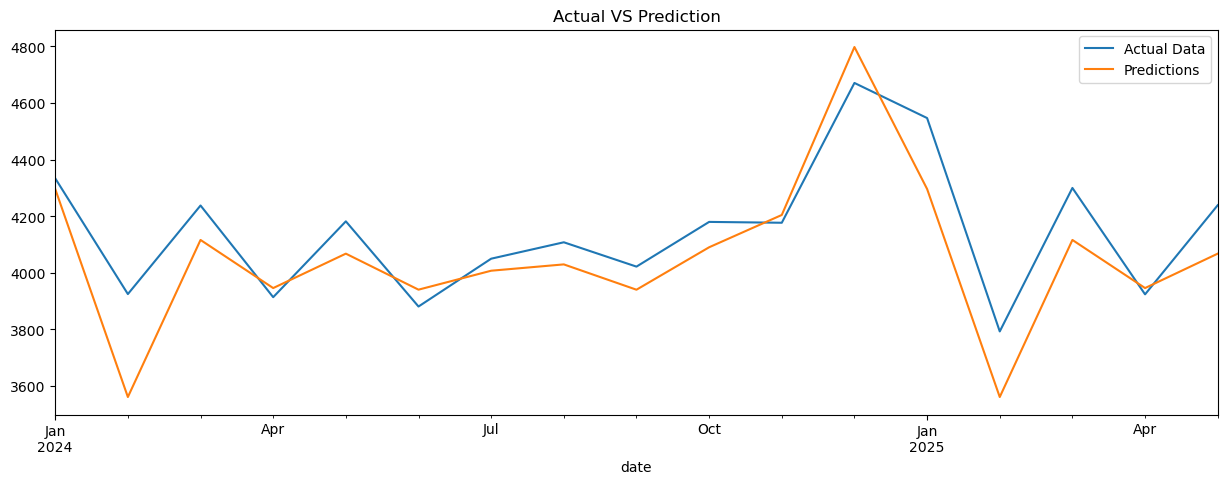

In [150]:
filtered_df = final_df[final_df.index >= '2024-01']
ax = filtered_df[['retail_sales_value_estimated']].plot(figsize=(15,5))
filtered_df['prediction'].plot(ax=ax,style='-')
plt.legend(['Actual Data','Predictions'])
ax.set_title('Actual VS Prediction')
plt.show()

In [153]:
# Final Model Building

FEATURES = ['quarter', 'month', 'year', 'is_covid']
TARGET = 'retail_sales_value_estimated'

X_full = df[FEATURES]
y_full = df[TARGET]

In [154]:
reg = xgb.XGBRegressor(
    base_score=0.5,
    booster='gbtree',
    n_estimators=1000,
    early_stopping_rounds=50,
    objective='reg:squarederror',  # use this instead of 'reg:linear' (deprecated)
    max_depth=3,
    learning_rate=0.1
)

reg.fit(X_full, y_full, eval_set=[(X_full, y_full)], verbose=100)


[0]	validation_0-rmse:2808.45163
[100]	validation_0-rmse:93.45720
[200]	validation_0-rmse:78.05174
[300]	validation_0-rmse:71.21467
[400]	validation_0-rmse:67.26833
[500]	validation_0-rmse:64.82634
[600]	validation_0-rmse:62.59829
[700]	validation_0-rmse:60.20918
[800]	validation_0-rmse:58.22086
[900]	validation_0-rmse:56.20489
[999]	validation_0-rmse:53.97597


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

In [155]:
# Forecasting Two Years, starting from 2025 May, so 19 months.
forecast_horizon = 19  
last_date = df.index.max()

In [167]:
last_date

Period('2025-05', 'M')

In [169]:
last_date_ts = last_date.to_timestamp(how='end')

In [172]:
# Month-end aligned
future_dates = pd.date_range(start=last_date_ts + pd.offsets.MonthEnd(1), periods=19, freq='M')

# Then convert to PeriodIndex with the same frequency
future_df = pd.DataFrame(index=pd.PeriodIndex(future_dates, freq='M'))

# Create time features
future_df['year'] = future_df.index.year
future_df['month'] = future_df.index.month
future_df['quarter'] = future_df.index.quarter
future_df['is_covid'] = 0 

In [175]:
future_df

,year,month,quarter,is_covid
2025-06,2025,6,2,0
2025-07,2025,7,3,0
2025-08,2025,8,3,0
2025-09,2025,9,3,0
2025-10,2025,10,4,0
2025-11,2025,11,4,0
2025-12,2025,12,4,0
2026-01,2026,1,1,0
2026-02,2026,2,1,0
2026-03,2026,3,1,0


In [176]:
X_future = future_df[FEATURES]
future_preds = reg.predict(X_future)
future_df['forecast'] = future_preds

In [177]:
df_results = pd.concat([
    df[['retail_sales_value_estimated']].copy(),
    future_df[['forecast']]
], axis=0)

In [179]:
df_results

,retail_sales_value_estimated,forecast
1997-01,2656.0,NaN
1997-02,1703.0,NaN
1997-03,2027.0,NaN
1997-04,1934.0,NaN
1997-05,1961.0,NaN
...,...,...
2026-08,NaN,4195.124512
2026-09,NaN,4120.995605
2026-10,NaN,4252.976074
2026-11,NaN,4281.727051


In [181]:
final_df

,retail_sales_value_estimated,is_covid,month,quarter,year,prediction
date,,,,,,
1997-01,2656,0,1,1,1997,NaN
1997-02,1703,0,2,1,1997,NaN
1997-03,2027,0,3,1,1997,NaN
1997-04,1934,0,4,2,1997,NaN
1997-05,1961,0,5,2,1997,NaN
...,...,...,...,...,...,...
2025-01,4547,0,1,1,2025,4296.314941
2025-02,3793,0,2,1,2025,3561.195312
2025-03,4300,0,3,1,2025,4116.237305


In [182]:
#export
final_df.to_csv('predicted.csv')
df_results.to_csv('forecasted.csv')